##Week 4

In [27]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
!pip install contractions

In [29]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import re
import spacy
from nltk.corpus import stopwords
import contractions
import matplotlib.pyplot as plt
import numpy as np

In [30]:
df = pd.read_csv('week_3_final_dataset.csv')


Removing the Live and Time columns as we no longer want to use it



In [31]:
df = df.drop(columns=['Live', 'Time'])


Slightly altered the week 3 eda notebook to re-catagorize subgenres that had fewer than 15 instances, now only 42 total subgenres exist



In [32]:
subgenre_counts = df['Subgenre'].value_counts()
subgenre_counts


,count
Subgenre,
hip hop,272
indie rock,207
indie pop,203
pop 80s,168
alternative rock,163
rock 70s,148
rock 80s,144
country,130
pop,124


Preparing the data for tokenization by cleaning the lyrics, also removing stop words and lemanizing the lyrics

Making sure the contractions are handled before the spacy function runs. This will keep the sentiment attached to the words.

In [33]:
def replace_s_with_is(text):
    # This replaces 's when it appears as a contraction (e.g. "Tonight's" -> "Tonight is")
    return re.sub(r"\b(\w+)'s\b", r"\1 is", text)

In [34]:
def expand_contractions(text):
    return contractions.fix(text) if isinstance(text, str) else text

df['Lyrics'] = df['Lyrics'].apply(expand_contractions)
df['Lyrics'] = df['Lyrics'].apply(replace_s_with_is)

In [35]:
df.head()


,Song,Artist,Popularity,BPM,Dance,Energy,Acoustic,Happy,Loud,Camelot,Lyrics,Genre,Subgenre
0,I'm So Excited,The Pointer Sisters,65,92,69,86,10,69,-6,4B,Tonight is the night we are going to make it h...,pop,pop 80s
1,Cheri Cheri Lady,Modern Talking,82,114,68,62,46,85,-14,6B,"Oh, I cannot explain\nEvery time, it is the sa...",pop,pop 80s
2,Give It Up,KC & The Sunshine Band,58,126,84,65,8,84,-12,5B,Everybody wants you\nEverybody wants your love...,pop,pop
3,It's Raining Men - Single Version,The Weather Girls,50,136,66,93,46,46,-6,4A,Hi! Hi! We are your weather girls\n(Uh huh)\nA...,pop,pop
4,Take on Me,a-ha,89,84,57,90,2,88,-8,11A,"We are talking away\nNo, I do not know what I ...",pop,pop 80s


In [36]:
# Load spaCy model and stopwords
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(stopwords.words("english"))

def clean_lyrics(text):
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove [annotations like chorus/verse]
    text = re.sub(r"\[.*?\]", "", text)

    # Remove punctuation (except apostrophes)
    text = re.sub(r"[^a-z0-9'\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize with spaCy
    doc = nlp(text)

    # Lemmatize and remove stopwords
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and token.lemma_ not in stop_words]

    return " ".join(tokens)

In [37]:
df['Clean_Lyrics'] = df['Lyrics'].apply(clean_lyrics)


In [38]:
df = df.drop(columns='Lyrics')


In [39]:
# Split the data
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

Add interaction feature 'Power' before data splitting. Power = loud x energy.
Loud and energy have a high correlation coefficient:0.73, making it a good candidate for an interaction term.

In [40]:
# Add interaction term 'Power': Power = Loud * Energy
df['Power'] = df['Loud'] * df['Energy']

Visualize the numerical category distributions.

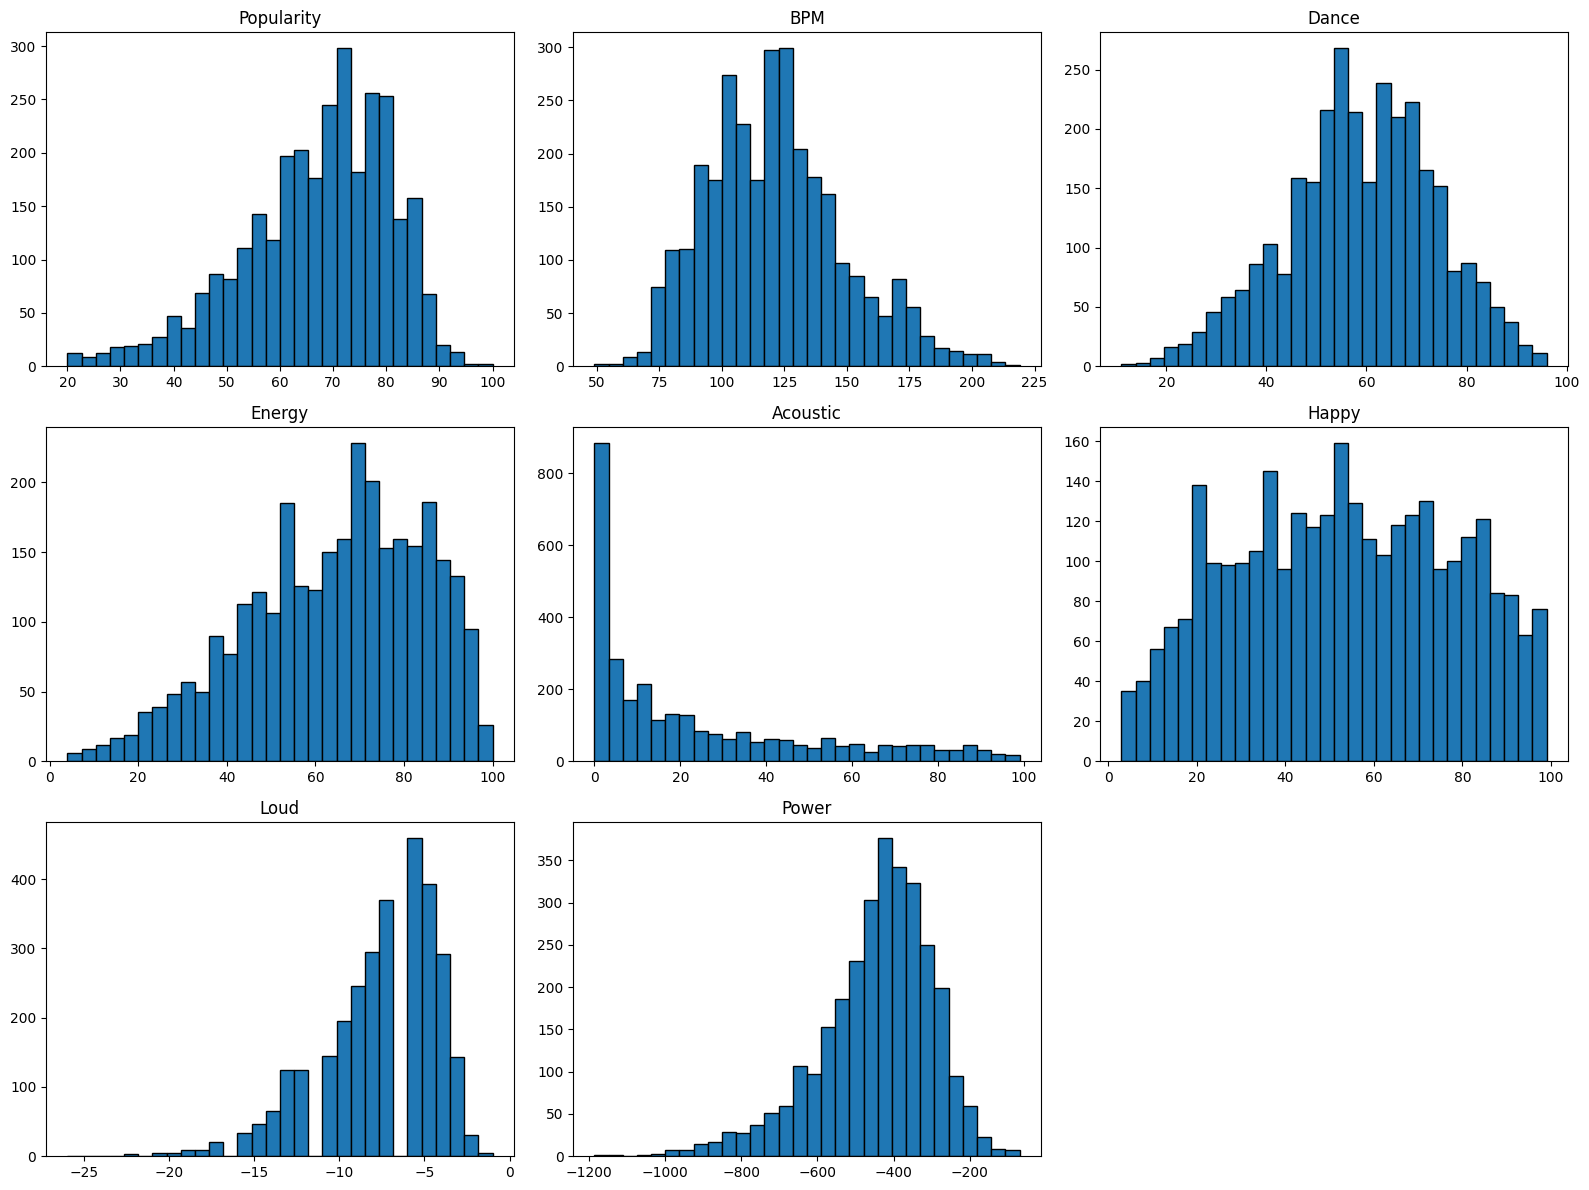

In [41]:
# List of numeric columns
numeric_cols = ['Popularity', 'BPM', 'Dance', 'Energy', 'Acoustic', 'Happy', 'Loud', 'Power']

# Set up subplots
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    plt.hist(df[col], bins=30, edgecolor='k')
    plt.title(col)

plt.tight_layout()
plt.show()


Transform acoustic with a log transformation.

In [42]:
# Apply square root to Acoustic
df['sqrt_Acoustic'] = np.sqrt(df['Acoustic'])

# Apply square root to BPM
df['sqrt_BPM'] = np.sqrt(df['BPM'])

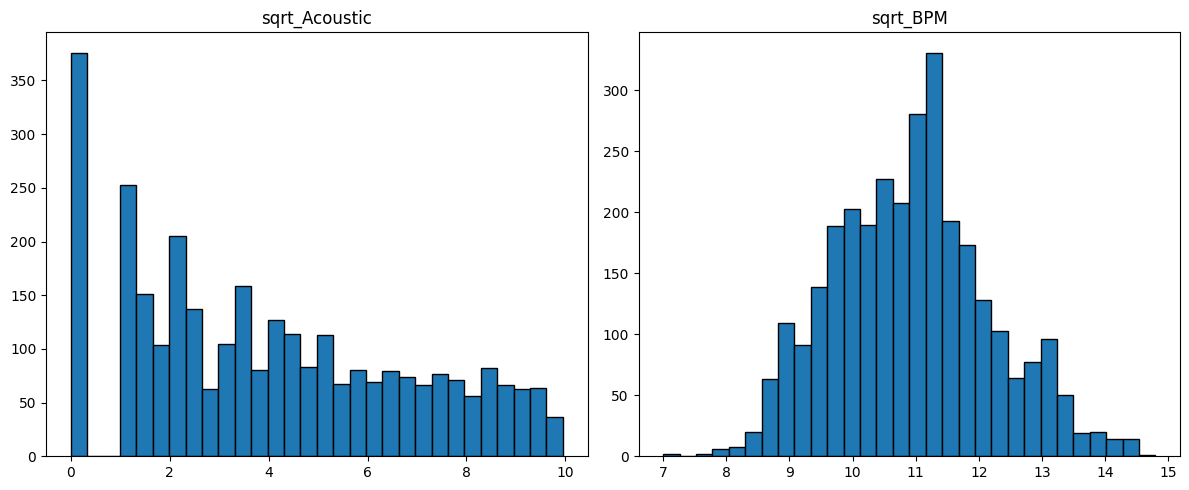

In [43]:
# List of transformed features
transformed_cols = ['sqrt_Acoustic', 'sqrt_BPM']

# Set up subplots
plt.figure(figsize=(12, 5))

for i, col in enumerate(transformed_cols, 1):
    plt.subplot(1, 2, i)
    plt.hist(df[col], bins=30, edgecolor='k')
    plt.title(col)

plt.tight_layout()
plt.show()


Split the data before feature normalization to prevent data leakage.

In [44]:
# Split the data
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
validation_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

Normalizing the numeric features on a 0 to 1 scale. Perform the normalization on the training data first. Then use the scalers from the training transformation to normalize the test and validation sets. This will prevent data leakage and prevent the model from over performing.

In [45]:
# Select only numeric columns
numeric_cols = train_df.select_dtypes(include='number').columns

# Create a scaler and fit-transform the numeric columns
scaler = MinMaxScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])

In [46]:
# Calculate the scaled means
scaled_means = train_df[numeric_cols].mean()

# Create a scaler summary DataFrame
scaler_summary = pd.DataFrame({
    'feature': numeric_cols,
    'original_min': scaler.data_min_,
    'original_max': scaler.data_max_,
    'scaler': scaler.scale_,          # 1 / (max - min)
    'scaled_mean': scaled_means.values
})

# Display
scaler_summary.set_index('feature', inplace=True)
display(scaler_summary)

,original_min,original_max,scaler,scaled_mean
feature,,,,
Popularity,20.0,100.000000,0.012500,0.588476
BPM,49.0,219.000000,0.005882,0.424823
Dance,11.0,96.000000,0.011765,0.565006
Energy,5.0,100.000000,0.010526,0.624075
Acoustic,0.0,99.000000,0.010101,0.235639
Happy,3.0,98.000000,0.010526,0.525564
Loud,-26.0,-1.000000,0.040000,0.731693
Power,-1036.0,-70.000000,0.001035,0.611998
sqrt_Acoustic,0.0,9.949874,0.100504,0.392503


In [47]:
# Apply the same transformation to validation and test sets
validation_df[numeric_cols] = scaler.transform(validation_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [48]:
# Save to CSV
train_df.to_csv("week_4_train_set.csv", index=False)
test_df.to_csv("week_4_test_set.csv", index=False)
validation_df.to_csv("week_4_validation_set.csv", index=False)

##Week 5 Beginning


In [49]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

import nltk
from nltk.tokenize import word_tokenize
!pip install gensim

from gensim.models.fasttext import load_facebook_vectors
from gensim.models import KeyedVectors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 8.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; 

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
df_test = pd.read_csv('week_4_test_set.csv')

df_train = pd.read_csv('week_4_train_set.csv')

df_val = pd.read_csv('week_4_validation_set.csv')


In [ ]:
df_train.head()

###Ryans additions


Camelot in practice is a circular scale. We could one hot encode 0-23, but 23 and 0 are just as close on the Camelot scale as 0 and 1. Instead we will code Camelot to have sin and cos coordinates (mapping on the unit circle) to better model songs in latent space.

In [ ]:
#Circular encoding for Camelot

def camelot_to_position(code):
    number = int(code[:-1])   # extract number (1-12)
    mode = code[-1]           # extract mode (A or B)
    mode_offset = 0 if mode == 'A' else 12        # Start at 0 if mode is A, if not start at 13
    return (number - 1) + mode_offset

def add_sin_cos(df):
    df['camelot_pos'] = df['Camelot'].map(camelot_to_position) #map camelot positions to 0-23
    df['camelot_sin'] = np.sin(2 * np.pi * df['camelot_pos'] / 24)        #compute sine transformation
    df['camelot_cos'] = np.cos(2 * np.pi * df['camelot_pos'] / 24)        #compute cosine transformation
    df.drop(['Camelot', 'camelot_pos'], axis=1, inplace=True)             #Drop camelot and intermediate position column.
    return df

#Apply transformation to train, test, val sets.
df_train = add_sin_cos(df_train)
df_val = add_sin_cos(df_val)
df_test = add_sin_cos(df_test)

Create a list of variables that we want to one-hot encode



In [ ]:
categorical_cols = ['Genre', 'Subgenre']


Fit the encoder to the train data first to prevent data leakage



In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(df_train[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [ ]:
# Helper function to transform and reattach
def encode_and_concat(df, encoder, categorical_cols):
    encoded = encoder.transform(df[categorical_cols])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)
    return pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)

In [ ]:
# Apply to each split
df_train_encoded = encode_and_concat(df_train, encoder, categorical_cols)
df_val_encoded = encode_and_concat(df_val, encoder, categorical_cols)
df_test_encoded = encode_and_concat(df_test, encoder, categorical_cols)

In [ ]:
df_val_encoded

In [ ]:
list(df_val_encoded.columns)



In [ ]:
df_train_encoded.head()

In [ ]:
nltk.download('punkt')


In [ ]:
def simple_tokenize(text):
  return text.split()

In [ ]:
# Apply to all three DataFrames
for df in [df_train_encoded, df_val_encoded, df_test_encoded]:
    df['Tokens'] = df['Clean_Lyrics'].apply(simple_tokenize)

In [ ]:
df_train_encoded.head()

In [ ]:
num_songs = len(df_train_encoded)

print(num_songs)

Because the number of songs is below 10000 we will use the FastText to vectorize the tokens. Download it here before running the code : https://fasttext.cc/docs/en/english-vectors.html. "English" - crawl-300d-2M-subword.zip

In [ ]:
#Change path to your own when running so no errors occur - the file can be found in the data folder for now
glove_path = '/Users/langleyburke/Downloads/crawl-300d-2M-subword/crawl-300d-2M-subword.vec'

fasttext_model = KeyedVectors.load_word2vec_format(glove_path, binary=False)

Testing to see if it is all set up properly.

In [ ]:
fasttext_model['love']

Seems like it is working, will now turn the tokenized lyrics into vectors so we can use them in our recommender model!

In [ ]:
def get_fasttext_embedding(tokens, model, dim=300):
    vectors = [model[word] for word in tokens if word in model]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

In [ ]:
#Creating new column 'Embeddings' for the final lyric conversions

for df in [df_train_encoded, df_val_encoded, df_test_encoded]:
    df['Embeddings'] = df['Tokens'].apply(lambda tokens: get_fasttext_embedding(tokens, fasttext_model))

df_train_encoded.head()

We can see now the tokens are in vector form and ready for use.